In [9]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore', message='.*SettingWithCopy.*')

# ── Configuration ─────────────────────────────────────────────────────────
FIRES_PATH  = 'oregon_fires_weather_merged.csv'
PRISM_PATH  = 'PRISM_2011-2016.csv'
OUT_PATH    = 'oregon_fires_weather_merged_with_prism.csv'
K_NEIGHBORS = 4
N_MONTHS    = 30
DEVICE      = 'cpu'  # change to 'cuda' or 'mps' if available
print('torch version:', torch.__version__)
print('device:', DEVICE)

torch version: 2.10.0
device: cpu


In [28]:
fires = pd.read_csv(FIRES_PATH, low_memory=False)
fires.columns = fires.columns.str.strip()
print(f'Loaded {len(fires):,} fire records')
print('Columns:', fires.columns.tolist())
fires.head(3)

Loaded 56,280 fire records
Columns: ['id', 'fire_year', 'report_date', 'county', 'latitude', 'longitude', 'total_acres', 'odf_acres', 'fuel_model', 'fuel_descr', 'general_cause', 'fire_name', 'district', 'unit', 'legal', 'LATITUDE', 'LONGITUDE', 'TEMP', 'MAX', 'MIN', 'DEWP', 'WDSP', 'MXSPD', 'PRCP', 'PRCP_30DAY', 'VPD_PROXY', 'TEMP_RANGE', 'FIRE_SEASON', 'MONTH', 'DOY', 'STATION_USED']


,id,fire_year,report_date,county,latitude,longitude,total_acres,odf_acres,fuel_model,fuel_descr,...,WDSP,MXSPD,PRCP,PRCP_30DAY,VPD_PROXY,TEMP_RANGE,FIRE_SEASON,MONTH,DOY,STATION_USED
0,9151,1970,1970-06-15,Tillamook,45.517000,-122.047000,0.05,0.05,X,non-wildland fuel,...,6.9,10.1,0.0,0.0,8.4,10.9,1.0,6.0,166.0,9.999992e+10
1,9152,1970,1970-06-22,Tillamook,45.498172,-122.044483,0.75,0.75,X,non-wildland fuel,...,7.6,15.0,0.0,0.0,18.3,27.0,1.0,6.0,173.0,9.999992e+10
2,9153,1970,1970-06-24,Tillamook,45.748014,-122.044125,10.00,10.00,X,non-wildland fuel,...,7.1,10.1,0.0,0.0,18.6,29.9,1.0,6.0,175.0,9.999992e+10


In [29]:
fires['report_date'] = pd.to_datetime(fires['report_date'], errors='coerce')

# Fall back to fire_year for missing dates
missing = fires['report_date'].isna()
if missing.any():
    print(f'{missing.sum()} rows missing report_date — using fire_year July 1 as fallback')
    fires.loc[missing, 'report_date'] = pd.to_datetime(
        fires.loc[missing, 'fire_year'].astype(str) + '-07-01'
    )

# Prefer station-matched coords, fall back to fire coords
fires['_lat'] = fires['LATITUDE'].fillna(fires['latitude'])
fires['_lon'] = fires['LONGITUDE'].fillna(fires['longitude'])

print(f'Date range: {fires["report_date"].min().date()} to {fires["report_date"].max().date()}')
print(f'Missing lat/lon: {(fires["_lat"].isna() | fires["_lon"].isna()).sum()}')
fires[['report_date', '_lat', '_lon']].head(3)

Date range: 1970-02-25 to 2021-05-28
Missing lat/lon: 0


,report_date,_lat,_lon
0,1970-06-15,45.59578,-122.60919
1,1970-06-22,45.59578,-122.60919
2,1970-06-24,45.59578,-122.60919


In [30]:
prism = pd.read_csv(PRISM_PATH, skiprows=10, low_memory=False)
prism.columns = prism.columns.str.strip()
print(f'Loaded {len(prism):,} PRISM rows')
print('Columns:', prism.columns.tolist())
prism.head(3)

Loaded 18,000 PRISM rows
Columns: ['Name', 'Longitude', 'Latitude', 'Elevation (ft)', 'Date', 'ppt (inches)', 'tmin (degrees F)', 'tmean (degrees F)', 'tmax (degrees F)']


,Name,Longitude,Latitude,Elevation (ft),Date,ppt (inches),tmin (degrees F),tmean (degrees F),tmax (degrees F)
0,Oregon Even,-124.2538,42.2126,1653,2011-03,29.90,37.7,42.6,47.5
1,Oregon Even,-124.2538,42.2126,1653,2011-04,11.54,37.1,44.7,52.3
2,Oregon Even,-124.2538,42.2126,1653,2011-05,6.41,40.7,49.1,57.6


In [31]:
fires['report_date'] = pd.to_datetime(fires['report_date'], errors='coerce')

# Fall back to fire_year for missing dates
missing = fires['report_date'].isna()
if missing.any():
    print(f'{missing.sum()} rows missing report_date — using fire_year July 1 as fallback')
    fires.loc[missing, 'report_date'] = pd.to_datetime(
        fires.loc[missing, 'fire_year'].astype(str) + '-07-01'
    )

# Prefer station-matched coords, fall back to fire coords
fires['_lat'] = fires['LATITUDE'].fillna(fires['latitude'])
fires['_lon'] = fires['LONGITUDE'].fillna(fires['longitude'])

print(f'Date range: {fires["report_date"].min().date()} to {fires["report_date"].max().date()}')
print(f'Missing lat/lon: {(fires["_lat"].isna() | fires["_lon"].isna()).sum()}')
fires[['report_date', '_lat', '_lon']].head(3)

Date range: 1970-02-25 to 2021-05-28
Missing lat/lon: 0


,report_date,_lat,_lon
0,1970-06-15,45.59578,-122.60919
1,1970-06-22,45.59578,-122.60919
2,1970-06-24,45.59578,-122.60919


In [32]:
prism = pd.read_csv(PRISM_PATH, skiprows=10, low_memory=False)
prism.columns = prism.columns.str.strip()
print(f'Loaded {len(prism):,} PRISM rows')
print('Columns:', prism.columns.tolist())
prism.head(3)

Loaded 18,000 PRISM rows
Columns: ['Name', 'Longitude', 'Latitude', 'Elevation (ft)', 'Date', 'ppt (inches)', 'tmin (degrees F)', 'tmean (degrees F)', 'tmax (degrees F)']


,Name,Longitude,Latitude,Elevation (ft),Date,ppt (inches),tmin (degrees F),tmean (degrees F),tmax (degrees F)
0,Oregon Even,-124.2538,42.2126,1653,2011-03,29.90,37.7,42.6,47.5
1,Oregon Even,-124.2538,42.2126,1653,2011-04,11.54,37.1,44.7,52.3
2,Oregon Even,-124.2538,42.2126,1653,2011-05,6.41,40.7,49.1,57.6


In [33]:
prism['Date'] = pd.to_datetime(prism['Date'], format='%Y-%m', errors='coerce')
prism = prism.dropna(subset=['Date', 'Latitude', 'Longitude', 'ppt (inches)'])
prism['year']  = prism['Date'].dt.year
prism['month'] = prism['Date'].dt.month

prism = (
    prism.groupby(['Name', 'Latitude', 'Longitude', 'year', 'month'], as_index=False)
    ['ppt (inches)'].mean()
)

n_pts = prism[['Latitude','Longitude']].drop_duplicates().shape[0]
print(f'{len(prism):,} station-month records across {n_pts} unique grid points')
print(f'Date range: {prism["year"].min()}-{prism["month"].min():02d} to {prism["year"].max()}-{prism["month"].max():02d}')
prism.head(3)

18,000 station-month records across 100 unique grid points
Date range: 2011-01 to 2026-12


,Name,Latitude,Longitude,year,month,ppt (inches)
0,Oregon Even,42.1227,-123.1923,2011,3,8.33
1,Oregon Even,42.1227,-123.1923,2011,4,3.01
2,Oregon Even,42.1227,-123.1923,2011,5,2.11


In [34]:
# Spatial index
pts  = prism[['Latitude', 'Longitude']].drop_duplicates().reset_index(drop=True)
tree = cKDTree(pts[['Latitude', 'Longitude']].values)
print(f'KD-tree built over {len(pts)} grid points')

# Fast dict lookup: (lat, lon, year, month) -> ppt
lookup = {
    (round(r.Latitude, 6), round(r.Longitude, 6), int(r.year), int(r.month)): r['ppt (inches)']
    for _, r in prism.iterrows()
}
print(f'Lookup table: {len(lookup):,} entries')

KD-tree built over 100 grid points
Lookup table: 18,000 entries


In [35]:
def get_precip_window(fire_lats, fire_lons, fire_dates, tree, pts, lookup,
                        mode='rolling', n_months=None, device='cpu'):
    """
    Compute IDW-interpolated precipitation sum for each fire.

    mode='rolling'      : sum over n_months rolling window ending at fire date
    mode='prior_winter' : sum Oct-Mar of the winter before the fire season
    mode='fire_month'   : ppt for the calendar month the fire occurred in
    """
    n = len(fire_lats)
    results = np.full(n, np.nan)

    valid_mask = ~(np.isnan(fire_lats) | np.isnan(fire_lons))
    if not valid_mask.any():
        return results

    coords = np.column_stack([fire_lats[valid_mask], fire_lons[valid_mask]])
    dists, idxs = tree.query(coords, k=min(4, len(pts)))
    if dists.ndim == 1:
        dists, idxs = dists[:, None], idxs[:, None]

    dists_t = torch.tensor(dists, dtype=torch.float32, device=device)
    w = 1.0 / (dists_t ** 2 + 1e-10)
    w = w / w.sum(dim=1, keepdim=True)

    for vi, fire_i in enumerate(np.where(valid_mask)[0]):
        fire_date       = fire_dates.iloc[fire_i]
        fire_year       = fire_date.year
        fire_month      = fire_date.month
        neighbor_coords = pts.iloc[idxs[vi]]

        if mode == 'rolling':
            periods = [(d.year, d.month)
                       for d in pd.date_range(end=fire_date, periods=n_months, freq='MS')]

        elif mode == 'prior_winter':
            # Oct-Mar ending before the fire's season
            # Fire Apr-Dec → prior winter = Oct(yr-1) through Mar(yr)
            # Fire Jan-Mar → prior winter = Oct(yr-2) through Mar(yr-1)
            winter_end_year = fire_year if fire_month >= 4 else fire_year - 1
            periods = [
                (winter_end_year - 1, 10), (winter_end_year - 1, 11), (winter_end_year - 1, 12),
                (winter_end_year,     1),  (winter_end_year,     2),  (winter_end_year,     3),
            ]

        elif mode == 'fire_month':
            periods = [(fire_year, fire_month)]

        monthly_total = torch.zeros(1, device=device)
        months_found  = 0

        for yr, mo in periods:
            ppt_vals = [
                lookup.get((round(nc.Latitude, 6), round(nc.Longitude, 6), yr, mo), np.nan)
                for _, nc in neighbor_coords.iterrows()
            ]
            ppt_t    = torch.tensor(ppt_vals, dtype=torch.float32, device=device)
            valid_nb = ~torch.isnan(ppt_t)
            if valid_nb.any():
                w_m = w[vi].clone()
                w_m[~valid_nb] = 0.0
                if w_m.sum() > 0:
                    w_m = w_m / w_m.sum()
                    monthly_total += (ppt_t * w_m)[valid_nb].sum()
                    months_found  += 1

        if months_found > 0:
            n_expected = n_months if mode == 'rolling' else (6 if mode == 'prior_winter' else 1)
            results[fire_i] = (monthly_total * (n_expected / months_found)).item()

    return results

In [36]:
fire_lats  = fires['_lat'].values.astype(float)
fire_lons  = fires['_lon'].values.astype(float)
fire_dates = fires['report_date']

print(f'Computing precipitation windows for {len(fires):,} fires...')

# Prior winter (Oct-Mar before fire season)
print('  -> prior winter (Oct-Mar)...')
fires['PRISM_PRCP_PRIOR_WINTER'] = get_precip_window(
    fire_lats, fire_lons, fire_dates, tree, pts, lookup,
    mode='prior_winter', device=DEVICE,
)

# Month of fire
print('  -> fire month...')
fires['PRISM_PRCP_FIRE_MONTH'] = get_precip_window(
    fire_lats, fire_lons, fire_dates, tree, pts, lookup,
    mode='fire_month', device=DEVICE,
)

valid_w = fires['PRISM_PRCP_PRIOR_WINTER'].notna()
valid_m = fires['PRISM_PRCP_FIRE_MONTH'].notna()
print(f'Prior winter filled: {valid_w.sum():,} / {len(fires):,}')
print(f'Fire month filled:   {valid_m.sum():,} / {len(fires):,}')
fires[['PRISM_PRCP_PRIOR_WINTER', 'PRISM_PRCP_FIRE_MONTH']].describe().round(3)

Computing precipitation windows for 56,280 fires...
  -> prior winter (Oct-Mar)...
  -> fire month...
Prior winter filled: 10,040 / 56,280
Fire month filled:   10,040 / 56,280


,PRISM_PRCP_PRIOR_WINTER,PRISM_PRCP_FIRE_MONTH
count,10040.000,10040.000
mean,23.489,0.948
std,18.651,1.532
min,4.599,0.000
25%,10.101,0.133
50%,16.355,0.483
75%,32.420,1.137
max,176.833,29.610


In [25]:
cols = ['report_date', 'PRCP_30DAY', 'PRISM_PRCP_PRIOR_WINTER', 'PRISM_PRCP_FIRE_MONTH']
fires[cols].dropna().head(10)

,report_date,PRCP_30DAY,PRISM_PRCP_PRIOR_WINTER,PRISM_PRCP_FIRE_MONTH
46095,2012-09-06,0.00,70.053177,0.116577
46235,2012-07-24,1.76,58.882893,0.785151
46236,2012-07-26,0.00,70.053177,0.733281
46237,2012-08-11,0.00,70.053177,0.039940
46238,2012-08-17,0.08,58.882893,0.024566
46239,2012-08-25,0.00,70.053177,0.039940
46240,2012-09-01,0.01,58.882893,0.119929
46241,2012-09-02,0.00,70.053177,0.116577
46242,2012-09-02,0.00,70.053177,0.116577
46243,2012-09-23,0.06,58.882893,0.119929


In [39]:
# Get PRISM year coverage from the loaded data
prism_min_year = prism['year'].min()
prism_max_year = prism['year'].max()
print(f'PRISM coverage: {prism_min_year} - {prism_max_year}')

# Drop rows where fire year is outside PRISM coverage (PRISM columns will be NaN)
in_range = fires["report_date"].dt.year.between(prism_min_year, prism_max_year)
out = fires[in_range].drop(columns=["_lat", "_lon"])
out.to_csv(OUT_PATH, index=False)
print(f'Kept {len(out):,} rows within PRISM range')
print(f'Dropped {(~in_range).sum():,} rows outside PRISM range')
print(f'Output: {out.shape[1]} columns')
print('New columns: PRISM_PRCP_PRIOR_WINTER, PRISM_PRCP_FIRE_MONTH')

PRISM coverage: 2011 - 2026
Kept 10,046 rows within PRISM range
Dropped 46,234 rows outside PRISM range
Output: 33 columns
New columns: PRISM_PRCP_PRIOR_WINTER, PRISM_PRCP_FIRE_MONTH


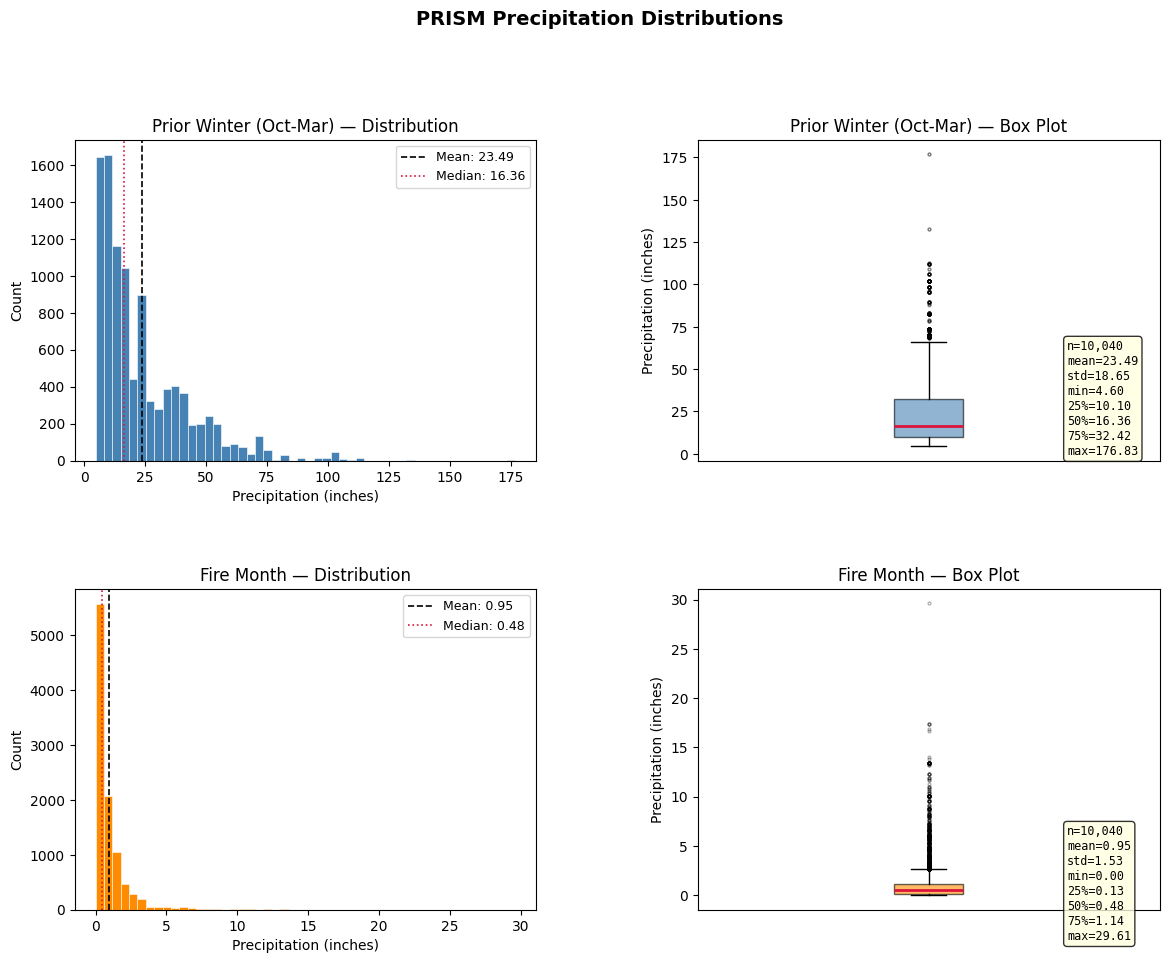


Summary statistics:
       PRISM_PRCP_PRIOR_WINTER  PRISM_PRCP_FIRE_MONTH
count                10040.000              10040.000
mean                    23.489                  0.948
std                     18.651                  1.532
min                      4.599                  0.000
25%                     10.101                  0.133
50%                     16.355                  0.483
75%                     32.420                  1.137
max                    176.833                 29.610

Pearson r(prior_winter, fire_month): 0.282


In [40]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

prism_cols = ['PRISM_PRCP_PRIOR_WINTER', 'PRISM_PRCP_FIRE_MONTH']
labels     = ['Prior Winter (Oct-Mar)', 'Fire Month']
colors     = ['steelblue', 'darkorange']

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

for i, (col, label, color) in enumerate(zip(prism_cols, labels, colors)):
    data = fires[col].dropna()

    # Histogram
    ax1 = fig.add_subplot(gs[i, 0])
    ax1.hist(data, bins=50, color=color, edgecolor='white', linewidth=0.4)
    ax1.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax1.axvline(data.median(), color='crimson', linestyle=':',  linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax1.set_title(f'{label} — Distribution')
    ax1.set_xlabel('Precipitation (inches)')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=9)

    # Box plot
    ax2 = fig.add_subplot(gs[i, 1])
    ax2.boxplot(data, vert=True, patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.6),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax2.set_title(f'{label} — Box Plot')
    ax2.set_ylabel('Precipitation (inches)')
    ax2.set_xticks([])

    stats = data.describe()
    stat_text = (
        f"n={int(stats['count']):,}\n"
        f"mean={stats['mean']:.2f}\n"
        f"std={stats['std']:.2f}\n"
        f"min={stats['min']:.2f}\n"
        f"25%={stats['25%']:.2f}\n"
        f"50%={stats['50%']:.2f}\n"
        f"75%={stats['75%']:.2f}\n"
        f"max={stats['max']:.2f}"
    )
    ax2.text(1.3, stats['75%'], stat_text, fontsize=8.5,
             verticalalignment='center', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('PRISM Precipitation Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('prism_precip_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSummary statistics:')
print(fires[prism_cols].describe().round(3).to_string())

corr = fires[prism_cols].corr().iloc[0, 1]
print(f'\nPearson r(prior_winter, fire_month): {corr:.3f}')